In [1]:
import pandas as pd

rates = pd.read_csv("../user_movie_rates.csv")
users = pd.read_csv("../users.csv")
movies = pd.read_csv("../movies.csv")

age_groups = pd.read_csv("../age_groups.csv")
occupations = pd.read_csv("../occupations.csv")

movie_genres = pd.read_csv("../movie_genres.csv")
genres = pd.read_csv("../genres.csv")

movie_actors = pd.read_csv("../movie_actors.csv")
actors = pd.read_csv("../actors.csv")

movie_directors = pd.read_csv("../movie_directors.csv")
directors = pd.read_csv("../directors.csv")

movie_countries = pd.read_csv("../movie_countries.csv")
countries = pd.read_csv("../countries.csv")

movie_tag = pd.read_csv("../movie_tag.csv")
tags = pd.read_csv("../tags.csv")

mpaa_rates = pd.read_csv("../mpaa_rates.csv")

print("rates:", rates.shape, rates.columns.tolist())
print("users:", users.shape, users.columns.tolist())
print("movies:", movies.shape, movies.columns.tolist())

print("age_groups:", age_groups.shape, age_groups.columns.tolist())
print("occupations:", occupations.shape, occupations.columns.tolist())

print("movie_genres:", movie_genres.shape, movie_genres.columns.tolist())
print("genres:", genres.shape, genres.columns.tolist())

print("movie_actors:", movie_actors.shape, movie_actors.columns.tolist())
print("actors:", actors.shape, actors.columns.tolist())

print("movie_directors:", movie_directors.shape, movie_directors.columns.tolist())
print("directors:", directors.shape, directors.columns.tolist())

print("movie_countries:", movie_countries.shape, movie_countries.columns.tolist())
print("countries:", countries.shape, countries.columns.tolist())

print("movie_tag:", movie_tag.shape, movie_tag.columns.tolist())
print("tags:", tags.shape, tags.columns.tolist())

print("mpaa_rates:", mpaa_rates.shape, mpaa_rates.columns.tolist())

rates: (948367, 4) ['user_id', 'movie_id', 'rating', 'datetime']
users: (6040, 4) ['user_id', 'gender', 'occupation', 'age_group_id']
movies: (3433, 7) ['movie_id', 'title', 'year', 'rated', 'plot', 'imdb_rating', 'imdb_id']
age_groups: (7, 2) ['group_id', 'group_label']
occupations: (21, 2) ['occ_id', 'occ_name']
movie_genres: (6408, 2) ['movie_id', 'genre_id']
genres: (18, 2) ['genre_id', 'name']
movie_actors: (10285, 2) ['movie_id', 'actor_id']
actors: (4965, 2) ['actor_id', 'actor']
movie_directors: (3676, 2) ['movie_id', 'director_id']
directors: (1918, 2) ['director_id', 'director']
movie_countries: (4765, 2) ['movie_id', 'country_id']
countries: (84, 2) ['country_id', 'country']
movie_tag: (450912, 2) ['movie_id', 'tag_id']
tags: (48075, 2) ['tag_id', 'tag_name']
mpaa_rates: (5, 2) ['rate_id', 'rate_name']


In [2]:
user_features_base = users[["user_id", "gender", "occupation", "age_group_id"]].copy()
user_features_base.head()

,user_id,gender,occupation,age_group_id
0,1,F,11,1
1,2,M,17,7
2,3,M,16,3
3,4,M,8,5
4,5,M,21,3


In [3]:
movies.head()

,movie_id,title,year,rated,plot,imdb_rating,imdb_id
0,1,Toy Story,1995,4.0,A cowboy doll is profoundly jealous when a new...,8.3,tt0114709
1,2,Jumanji,1995,2.0,A magic board game summons jungle perils and a...,7.1,tt0113497
2,3,Grumpier Old Men,1995,3.0,Just as John and Max resolve to save their bel...,6.7,tt0113228
3,4,Waiting to Exhale,1995,1.0,"Based on Terry McMillan's novel, this film fol...",6.0,tt0114885
4,5,Father of the Bride Part II,1995,2.0,George Banks must deal not only with his daugh...,6.1,tt0113041


In [4]:
from common.feature_engineering import build_user_feature_tokens

user_feature_map = build_user_feature_tokens(user_features_base)
list(user_feature_map.items())[:5]

[(1, ['age_group:1', 'gender:F', 'occupation:11']),
 (2, ['age_group:7', 'gender:M', 'occupation:17']),
 (3, ['age_group:3', 'gender:M', 'occupation:16']),
 (4, ['age_group:5', 'gender:M', 'occupation:8']),
 (5, ['age_group:3', 'gender:M', 'occupation:21'])]

In [5]:
from collections import Counter
import pandas as pd

def _choose_id_col(df: pd.DataFrame, candidates: list[str]) -> str:
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"None of candidate columns {candidates} found in DataFrame")

def _attach_name(
    rel_df: pd.DataFrame,
    value_df: pd.DataFrame | None,
    rel_value_col_candidates: list[str],
    value_id_col_candidates: list[str],
    value_name_col_candidates: list[str],
) -> pd.DataFrame:
    rel = rel_df.copy()
    rel_value_col = _choose_id_col(rel, rel_value_col_candidates)

    if value_df is None:
        rel["token_value"] = rel[rel_value_col].astype(str)
        return rel

    value = value_df.copy()
    value_id_col = _choose_id_col(value, value_id_col_candidates)
    value_name_col = _choose_id_col(value, value_name_col_candidates)

    merged = rel.merge(
        value[[value_id_col, value_name_col]].drop_duplicates(),
        left_on=rel_value_col,
        right_on=value_id_col,
        how="left",
    )
    merged["token_value"] = merged[value_name_col].fillna(merged[rel_value_col].astype(str))
    return merged

def build_progressive_item_feature_maps(
    movie_genres: pd.DataFrame,
    movie_directors: pd.DataFrame,
    movie_actors: pd.DataFrame,
    movie_countries: pd.DataFrame,
    genres: pd.DataFrame | None = None,
    directors: pd.DataFrame | None = None,
    actors: pd.DataFrame | None = None,
    countries: pd.DataFrame | None = None,
    top_n_directors: int = 200,
    top_n_actors: int = 200,
) -> dict[str, dict[int, list[str]]]:
    movie_id_col = _choose_id_col(movie_genres, ["movie_id", "item_id"])

    genre_rel = _attach_name(
        movie_genres, genres,
        rel_value_col_candidates=["genre_id", "genre", "name"],
        value_id_col_candidates=["genre_id", "id"],
        value_name_col_candidates=["genre", "name"],
    )
    director_rel = _attach_name(
        movie_directors, directors,
        rel_value_col_candidates=["director_id", "director", "name"],
        value_id_col_candidates=["director_id", "id"],
        value_name_col_candidates=["director", "name"],
    )
    actor_rel = _attach_name(
        movie_actors, actors,
        rel_value_col_candidates=["actor_id", "actor", "name"],
        value_id_col_candidates=["actor_id", "id"],
        value_name_col_candidates=["actor", "name"],
    )
    country_rel = _attach_name(
        movie_countries, countries,
        rel_value_col_candidates=["country_id", "country", "name"],
        value_id_col_candidates=["country_id", "id"],
        value_name_col_candidates=["country", "name"],
    )

    if len(director_rel):
        top_directors = set(director_rel["token_value"].value_counts().head(top_n_directors).index)
        director_rel = director_rel[director_rel["token_value"].isin(top_directors)].copy()

    if len(actor_rel):
        top_actors = set(actor_rel["token_value"].value_counts().head(top_n_actors).index)
        actor_rel = actor_rel[actor_rel["token_value"].isin(top_actors)].copy()

    base_movie_ids = sorted(pd.Index(movie_genres[movie_id_col].unique()).union(movie_directors[movie_id_col].unique()).union(movie_actors[movie_id_col].unique()).union(movie_countries[movie_id_col].unique()))
    current = {int(movie_id): [] for movie_id in base_movie_ids}

    def add_tokens(rel_df: pd.DataFrame, prefix: str):
        nonlocal current
        if rel_df.empty:
            return
        rel_movie_id_col = _choose_id_col(rel_df, ["movie_id", "item_id"])
        grouped = (
            rel_df.assign(token=prefix + ":" + rel_df["token_value"].astype(str))
            .groupby(rel_movie_id_col)["token"]
            .apply(lambda s: sorted(set(s)))
            .to_dict()
        )
        for movie_id, tokens in grouped.items():
            movie_id = int(movie_id)
            current.setdefault(movie_id, [])
            current[movie_id].extend(tokens)
            current[movie_id] = sorted(set(current[movie_id]))

    progressive = {"raw": {movie_id: [] for movie_id in base_movie_ids}}
    add_tokens(genre_rel, "genre")
    progressive["genres"] = {k: v.copy() for k, v in current.items()}
    add_tokens(director_rel, "director")
    progressive["genres_directors"] = {k: v.copy() for k, v in current.items()}
    add_tokens(actor_rel, "actor")
    progressive["genres_directors_actors"] = {k: v.copy() for k, v in current.items()}
    add_tokens(country_rel, "country")
    progressive["genres_directors_actors_countries"] = {k: v.copy() for k, v in current.items()}

    return progressive

progressive_item_feature_maps = build_progressive_item_feature_maps(
    movie_genres=movie_genres,
    movie_directors=movie_directors,
    movie_actors=movie_actors,
    movie_countries=movie_countries,
    genres=globals().get("genres"),
    directors=globals().get("directors"),
    actors=globals().get("actors"),
    countries=globals().get("countries"),
    top_n_directors=200,
    top_n_actors=200,
)

{k: len(v) for k, v in progressive_item_feature_maps.items()}

{'raw': 3883,
 'genres': 3883,
 'genres_directors': 3883,
 'genres_directors_actors': 3883,
 'genres_directors_actors_countries': 3883}

In [6]:
context_order = [
    "raw",
    "genres",
    "genres_directors",
    "genres_directors_actors",
    "genres_directors_actors_countries",
]

context_labels = {
    "raw": "Raw LightFM",
    "genres": "Genres",
    "genres_directors": "Genres + Directors",
    "genres_directors_actors": "Genres + Directors + Actors",
    "genres_directors_actors_countries": "Genres + Directors + Actors + Countries",
}

context_order

['raw',
 'genres',
 'genres_directors',
 'genres_directors_actors',
 'genres_directors_actors_countries']

In [7]:
for stage in context_order:
    token_count = len({
        token
        for tokens in progressive_item_feature_maps[stage].values()
        for token in tokens
    })
    print(f"{stage}: movies={len(progressive_item_feature_maps[stage])}, unique_item_tokens={token_count}")

raw: movies=3883, unique_item_tokens=0
genres: movies=3883, unique_item_tokens=18
genres_directors: movies=3883, unique_item_tokens=218
genres_directors_actors: movies=3883, unique_item_tokens=418
genres_directors_actors_countries: movies=3883, unique_item_tokens=502


In [15]:
!pip install --upgrade pip

In [16]:
!pip install lightfm-next

In [8]:
thresholds = [3.0, 4.0, 5.0]
min_pos_values = [5, 10, 20]
TEST_RATIO = 0.2

experiments = []

for threshold in thresholds:
    for min_pos in min_pos_values:
        experiments.append({
            "threshold": threshold,
            "min_pos": min_pos,
            "experiment": f"thr_{threshold}_minpos_{min_pos}"
        })

experiments

[{'threshold': 3.0, 'min_pos': 5, 'experiment': 'thr_3.0_minpos_5'},
 {'threshold': 3.0, 'min_pos': 10, 'experiment': 'thr_3.0_minpos_10'},
 {'threshold': 3.0, 'min_pos': 20, 'experiment': 'thr_3.0_minpos_20'},
 {'threshold': 4.0, 'min_pos': 5, 'experiment': 'thr_4.0_minpos_5'},
 {'threshold': 4.0, 'min_pos': 10, 'experiment': 'thr_4.0_minpos_10'},
 {'threshold': 4.0, 'min_pos': 20, 'experiment': 'thr_4.0_minpos_20'},
 {'threshold': 5.0, 'min_pos': 5, 'experiment': 'thr_5.0_minpos_5'},
 {'threshold': 5.0, 'min_pos': 10, 'experiment': 'thr_5.0_minpos_10'},
 {'threshold': 5.0, 'min_pos': 20, 'experiment': 'thr_5.0_minpos_20'}]

In [9]:
from common.data_prep import build_edges, filter_users_min_pos
from common.split import temporal_train_test_split

splits = {}

for exp in experiments:
    threshold = exp["threshold"]
    min_pos = exp["min_pos"]
    exp_name = exp["experiment"]

    edges = build_edges(
        data=rates,
        threshold=threshold,
        user_col="user_id",
        item_col="movie_id",
        rating_col="rating",
        time_col="datetime",
    )

    edges = filter_users_min_pos(
        data=edges,
        min_pos=min_pos,
        user_col="user_id",
    )

    train_df, test_df = temporal_train_test_split(
        df_pos=edges,
        user_col="user_id",
        time_col="datetime",
        test_ratio=TEST_RATIO,
        min_train=1,
        min_test=1,
    )

    splits[exp_name] = {
        "threshold": threshold,
        "min_pos": min_pos,
        "train_df": train_df,
        "test_df": test_df,
        "split_type": "temporal_80_20",
    }

    print(
        exp_name,
        "| train:", train_df.shape,
        "| test:", test_df.shape,
        "| users:", train_df["user_id"].nunique(),
        "| items:", train_df["movie_id"].nunique(),
    )

thr_3.0_minpos_5 | train: (632944, 3) | test: (161279, 3) | users: 6038 | items: 3221
thr_3.0_minpos_10 | train: (632914, 3) | test: (161269, 3) | users: 6033 | items: 3221
thr_3.0_minpos_20 | train: (628284, 3) | test: (159931, 3) | users: 5673 | items: 3219
thr_4.0_minpos_5 | train: (434116, 3) | test: (111512, 3) | users: 6033 | items: 3135
thr_4.0_minpos_10 | train: (433568, 3) | test: (111329, 3) | users: 5937 | items: 3134
thr_4.0_minpos_20 | train: (423522, 3) | test: (108382, 3) | users: 5083 | items: 3126
thr_5.0_minpos_5 | train: (168107, 3) | test: (44791, 3) | users: 5614 | items: 2817
thr_5.0_minpos_10 | train: (163580, 3) | test: (43234, 3) | users: 4746 | items: 2810
thr_5.0_minpos_20 | train: (147627, 3) | test: (38534, 3) | users: 3282 | items: 2784


In [10]:
splits["thr_5.0_minpos_5"]["train_df"].head()

,user_id,movie_id,datetime
0,1,1270,2000-12-31 22:00:55+00:00
1,1,1022,2000-12-31 22:00:55+00:00
2,1,1836,2000-12-31 22:02:52+00:00
3,1,2804,2000-12-31 22:11:59+00:00
4,1,1193,2000-12-31 22:12:40+00:00


In [11]:
exp_name = "thr_5.0_minpos_5"
context_stage = "full_context"

train_df = splits[exp_name]["train_df"]
test_df = splits[exp_name]["test_df"]

train_user_ids = sorted(train_df["user_id"].unique())
train_item_ids = sorted(train_df["movie_id"].unique())

movie_feature_map_train = {
    movie_id: progressive_item_feature_maps[
        "genres_directors_actors_countries"
        if context_stage == "full_context" else context_stage
    ].get(movie_id, [])
    for movie_id in train_item_ids
}

user_feature_map_train = {
    user_id: user_feature_map.get(user_id, [])
    for user_id in train_user_ids
}

In [12]:
from lightfm.data import Dataset

all_item_features = sorted({
    token
    for tokens in movie_feature_map_train.values()
    for token in tokens
})

all_user_features = sorted({
    token
    for tokens in user_feature_map_train.values()
    for token in tokens
})

dataset = Dataset()

if context_stage == "raw":
    dataset.fit(
        users=train_user_ids,
        items=train_item_ids,
    )
elif context_stage == "full_context":
    dataset.fit(
        users=train_user_ids,
        items=train_item_ids,
        user_features=all_user_features,
        item_features=all_item_features,
    )
else:
    dataset.fit(
        users=train_user_ids,
        items=train_item_ids,
        item_features=all_item_features,
    )

/Users/alexandro/DataspellProjects/recommend-system/.venv/lib/python3.12/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


In [13]:
print(len(train_user_ids), len(train_item_ids))
print(len(all_user_features), len(all_item_features))

5614 2817
30 496


In [14]:
train_pairs = list(zip(train_df["user_id"], train_df["movie_id"]))

interactions, weights = dataset.build_interactions(train_pairs)

In [15]:
item_feature_tuples = [
    (movie_id, movie_feature_map_train[movie_id])
    for movie_id in train_item_ids
]

item_features = None if context_stage == "raw" else dataset.build_item_features(item_feature_tuples)

user_feature_tuples = [
    (user_id, user_feature_map_train[user_id])
    for user_id in train_user_ids
]

user_features = (
    dataset.build_user_features(user_feature_tuples)
    if context_stage == "full_context"
    else None
)

item_features

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 15027 stored elements and shape (2817, 3313)>

In [16]:
print("item feature matrix:", None if item_features is None else item_features.shape)
print("user feature matrix:", None if user_features is None else user_features.shape)

item feature matrix: (2817, 3313)
user feature matrix: (5614, 5644)


In [17]:
print("interactions:", interactions.shape, interactions.nnz)

interactions: (5614, 2817) 168107


In [18]:
from lightfm import LightFM

model = LightFM(
    no_components=64,
    loss="warp",
    learning_rate=0.05,
    random_state=42
)

model.fit(
    interactions=interactions,
    item_features=item_features,
    user_features=user_features,
    epochs=20,
    num_threads=4,
    verbose=True
)

Epoch: 100%|██████████| 20/20 [00:06<00:00,  3.22it/s]


In [19]:
from common.eval import build_user_item_dict

ground_truth = build_user_item_dict(test_df)

In [20]:
user_id_map, user_feature_map_ds, item_id_map, item_feature_map_ds = dataset.mapping()
len(user_id_map), len(item_id_map)

(5614, 2817)

In [21]:
import numpy as np

K = 10
recommendations = {}

train_user_items = (
    train_df.groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

all_item_ids = np.array(train_item_ids)

for user_id in ground_truth.keys():
    if user_id not in user_id_map:
        continue

    user_idx = user_id_map[user_id]

    scores = model.predict(
        user_ids=user_idx,
        item_ids=np.arange(len(train_item_ids)),
        item_features=item_features,
        user_features=user_features,
    )

    seen_items = train_user_items.get(user_id, set())

    candidate_pairs = [
        (item_id, score)
        for item_id, score in zip(all_item_ids, scores)
        if item_id not in seen_items
    ]

    candidate_pairs.sort(key=lambda x: x[1], reverse=True)

    recommendations[user_id] = [item_id for item_id, _ in candidate_pairs[:K]]

In [22]:
from common.eval import evaluate_ranking

metrics = evaluate_ranking(
    recommendations=recommendations,
    ground_truth=ground_truth,
    k=K,
)

metrics

{'precision': np.float64(0.047506234413965086),
 'recall': np.float64(0.07747011783020397),
 'map': np.float64(0.0326452402135431),
 'ndcg': np.float64(0.06920211648456775),
 'mrr': np.float64(0.12136248098574426),
 'hitrate': np.float64(0.32401140007125045)}

In [34]:
thresholds = [3.0, 4.0, 5.0]
min_pos_values = [5, 10, 20]
K = [5, 10, 20]
NUM_THREADS = 8

NO_COMPONENTS = [64]
EPOCHS_LIST = [80]
LEARNING_RATES = [0.05]
LOSSES = ["warp"]

context_order = [
    "raw",
    "genres",
    "genres_directors",
    "genres_directors_actors",
    "genres_directors_actors_countries",
]

experiments = []

for threshold in thresholds:
    for min_pos in min_pos_values:
        experiments.append({
            "threshold": threshold,
            "min_pos": min_pos,
            "experiment": f"thr_{threshold}_minpos_{min_pos}"
        })

experiments

[{'threshold': 3.0, 'min_pos': 5, 'experiment': 'thr_3.0_minpos_5'},
 {'threshold': 3.0, 'min_pos': 10, 'experiment': 'thr_3.0_minpos_10'},
 {'threshold': 3.0, 'min_pos': 20, 'experiment': 'thr_3.0_minpos_20'},
 {'threshold': 4.0, 'min_pos': 5, 'experiment': 'thr_4.0_minpos_5'},
 {'threshold': 4.0, 'min_pos': 10, 'experiment': 'thr_4.0_minpos_10'},
 {'threshold': 4.0, 'min_pos': 20, 'experiment': 'thr_4.0_minpos_20'},
 {'threshold': 5.0, 'min_pos': 5, 'experiment': 'thr_5.0_minpos_5'},
 {'threshold': 5.0, 'min_pos': 10, 'experiment': 'thr_5.0_minpos_10'},
 {'threshold': 5.0, 'min_pos': 20, 'experiment': 'thr_5.0_minpos_20'}]

In [35]:
results = []

for exp in experiments:
    threshold = exp["threshold"]
    min_pos = exp["min_pos"]
    exp_name = exp["experiment"]

    print(f"\n{'=' * 80}")
    print(f"EXPERIMENT: {exp_name}")
    print(f"{'=' * 80}")

    edges = build_edges(
        data=rates,
        threshold=threshold,
        user_col="user_id",
        item_col="movie_id",
        rating_col="rating",
        time_col="datetime",
    )

    edges = filter_users_min_pos(
        data=edges,
        min_pos=min_pos,
        user_col="user_id",
    )

    train_df, test_df = temporal_train_test_split(
        df_pos=edges,
        user_col="user_id",
        time_col="datetime",
        test_ratio=0.2,
        min_train=1,
        min_test=1,
    )

    print(
        f"train={train_df.shape}, "
        f"test={test_df.shape}, "
        f"users={train_df['user_id'].nunique()}, "
        f"items={train_df['movie_id'].nunique()}"
    )

    train_user_ids = sorted(train_df["user_id"].unique())
    train_item_ids = sorted(train_df["movie_id"].unique())
    train_pairs = list(zip(train_df["user_id"], train_df["movie_id"]))

    ground_truth = build_user_item_dict(test_df)
    train_user_items = (
        train_df.groupby("user_id")["movie_id"]
        .apply(set)
        .to_dict()
    )
    all_item_ids = np.array(train_item_ids)

    for context_stage in context_order:
        print(f"  Context stage: {context_stage}")

        item_context_stage = (
            "genres_directors_actors_countries"
            if context_stage == "full_context"
            else context_stage
        )

        movie_feature_map_train = {
            movie_id: progressive_item_feature_maps[item_context_stage].get(movie_id, [])
            for movie_id in train_item_ids
        }

        user_feature_map_train = {
            user_id: user_feature_map.get(user_id, [])
            for user_id in train_user_ids
        }

        all_item_features = sorted({
            token
            for tokens in movie_feature_map_train.values()
            for token in tokens
        })

        all_user_features = sorted({
            token
            for tokens in user_feature_map_train.values()
            for token in tokens
        })

        dataset = Dataset()
        if context_stage == "raw":
            dataset.fit(
                users=train_user_ids,
                items=train_item_ids,
            )
        elif context_stage == "full_context":
            dataset.fit(
                users=train_user_ids,
                items=train_item_ids,
                user_features=all_user_features,
                item_features=all_item_features,
            )
        else:
            dataset.fit(
                users=train_user_ids,
                items=train_item_ids,
                item_features=all_item_features,
            )

        interactions, weights = dataset.build_interactions(train_pairs)

        item_feature_tuples = [
            (movie_id, movie_feature_map_train[movie_id])
            for movie_id in train_item_ids
        ]
        item_features = None if context_stage == "raw" else dataset.build_item_features(item_feature_tuples)

        user_feature_tuples = [
            (user_id, user_feature_map_train[user_id])
            for user_id in train_user_ids
        ]
        user_features = (
            dataset.build_user_features(user_feature_tuples)
            if context_stage == "full_context"
            else None
        )

        user_id_map, _, item_id_map, _ = dataset.mapping()

        for no_components in NO_COMPONENTS:
            for epochs in EPOCHS_LIST:
                for learning_rate in LEARNING_RATES:
                    LOSS_VALUES = LOSSES if "LOSSES" in globals() else ["warp"]
                    for loss in LOSS_VALUES:
                        print(
                            f"    params: comp={no_components}, "
                            f"epochs={epochs}, lr={learning_rate}, loss={loss}"
                        )

                        model = LightFM(
                            no_components=no_components,
                            loss=loss,
                            learning_rate=learning_rate,
                            random_state=42,
                        )

                        model.fit(
                            interactions=interactions,
                            item_features=item_features,
                            user_features=user_features,
                            epochs=epochs,
                            num_threads=NUM_THREADS,
                            verbose=False,
                        )

                        for k in K:
                            recommendations = {}

                            for user_id in ground_truth.keys():
                                if user_id not in user_id_map:
                                    continue

                                user_idx = user_id_map[user_id]
                                scores = model.predict(
                                    user_ids=user_idx,
                                    item_ids=np.arange(len(train_item_ids)),
                                    item_features=item_features,
                                    user_features=user_features,
                                )

                                seen_items = train_user_items.get(user_id, set())
                                candidate_pairs = [
                                    (item_id, score)
                                    for item_id, score in zip(all_item_ids, scores)
                                    if item_id not in seen_items
                                ]
                                candidate_pairs.sort(key=lambda x: x[1], reverse=True)
                                recommendations[user_id] = [item_id for item_id, _ in candidate_pairs[:k]]

                            metrics = evaluate_ranking(
                                recommendations=recommendations,
                                ground_truth=ground_truth,
                                k=k,
                            )

                            results.append({
                                "experiment": exp_name,
                                "threshold": threshold,
                                "min_pos": min_pos,
                                "split_type": "temporal_80_20",
                                "context_stage": context_stage,
                                "context_label": context_labels[context_stage],
                                "k": k,
                                "no_components": no_components,
                                "epochs": epochs,
                                "learning_rate": learning_rate,
                                "loss": loss,
                                "precision": metrics["precision"],
                                "recall": metrics["recall"],
                                "map": metrics["map"],
                                "ndcg": metrics["ndcg"],
                                "mrr": metrics["mrr"],
                                "hitrate": metrics["hitrate"],
                                "train_edges": len(train_df),
                                "test_edges": len(test_df),
                                "n_users": len(train_user_ids),
                                "n_items": len(train_item_ids),
                                "item_feature_dim": 0 if item_features is None else item_features.shape[1],
                                "user_feature_dim": 0 if user_features is None else user_features.shape[1],
                                "nnz": interactions.nnz,
                            })


lightfm_results_df = pd.DataFrame(results)
lightfm_results_df


EXPERIMENT: thr_3.0_minpos_5
train=(632944, 3), test=(161279, 3), users=6038, items=3221
  Context stage: raw
    params: comp=64, epochs=80, lr=0.05, loss=warp
  Context stage: genres
    params: comp=64, epochs=80, lr=0.05, loss=warp
  Context stage: genres_directors
    params: comp=64, epochs=80, lr=0.05, loss=warp
  Context stage: genres_directors_actors
    params: comp=64, epochs=80, lr=0.05, loss=warp
  Context stage: genres_directors_actors_countries
    params: comp=64, epochs=80, lr=0.05, loss=warp

EXPERIMENT: thr_3.0_minpos_10
train=(632914, 3), test=(161269, 3), users=6033, items=3221
  Context stage: raw
    params: comp=64, epochs=80, lr=0.05, loss=warp
  Context stage: genres
    params: comp=64, epochs=80, lr=0.05, loss=warp
  Context stage: genres_directors
    params: comp=64, epochs=80, lr=0.05, loss=warp
  Context stage: genres_directors_actors
    params: comp=64, epochs=80, lr=0.05, loss=warp
  Context stage: genres_directors_actors_countries
    params: comp=6

,experiment,threshold,min_pos,split_type,context_stage,context_label,k,no_components,epochs,learning_rate,...,ndcg,mrr,hitrate,train_edges,test_edges,n_users,n_items,item_feature_dim,user_feature_dim,nnz
0,thr_3.0_minpos_5,3.0,5,temporal_80_20,raw,Raw LightFM,5,64,80,0.05,...,0.119187,0.222709,0.394833,632944,161279,6038,3221,0,0,632944
1,thr_3.0_minpos_5,3.0,5,temporal_80_20,raw,Raw LightFM,10,64,80,0.05,...,0.120443,0.247039,0.578172,632944,161279,6038,3221,0,0,632944
2,thr_3.0_minpos_5,3.0,5,temporal_80_20,raw,Raw LightFM,20,64,80,0.05,...,0.132665,0.259726,0.760848,632944,161279,6038,3221,0,0,632944
3,thr_3.0_minpos_5,3.0,5,temporal_80_20,genres,Genres,5,64,80,0.05,...,0.123334,0.223142,0.392514,632944,161279,6038,3221,3239,0,632944
4,thr_3.0_minpos_5,3.0,5,temporal_80_20,genres,Genres,10,64,80,0.05,...,0.123995,0.245749,0.562769,632944,161279,6038,3221,3239,0,632944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,thr_5.0_minpos_20,5.0,20,temporal_80_20,genres_directors_actors,Genres + Directors + Actors,10,64,80,0.05,...,0.079202,0.164676,0.442108,147627,38534,3282,2784,3202,0,147627
131,thr_5.0_minpos_20,5.0,20,temporal_80_20,genres_directors_actors,Genres + Directors + Actors,20,64,80,0.05,...,0.099186,0.177406,0.627361,147627,38534,3282,2784,3202,0,147627
132,thr_5.0_minpos_20,5.0,20,temporal_80_20,genres_directors_actors_countries,Genres + Directors + Actors + Countries,5,64,80,0.05,...,0.071504,0.142967,0.273004,147627,38534,3282,2784,3280,0,147627
133,thr_5.0_minpos_20,5.0,20,temporal_80_20,genres_directors_actors_countries,Genres + Directors + Actors + Countries,10,64,80,0.05,...,0.077199,0.164039,0.435405,147627,38534,3282,2784,3280,0,147627


In [37]:
df = lightfm_results_df.copy()

numeric_cols = [
    "threshold", "min_pos", "precision", "recall", "map", "ndcg", "mrr", "hitrate",
    "train_edges", "test_edges", "n_users", "n_items",
    "item_feature_dim", "nnz", "k", "no_components", "epochs", "learning_rate"
]

for c in numeric_cols:
    df[c] = df[c].astype(float)

df["k"] = df["k"].astype(int)
df["min_pos"] = df["min_pos"].astype(int)

    threshold  min_pos   k    recall
90        5.0        5   5  0.051074
91        5.0        5  10  0.092201
92        5.0        5  20  0.156792


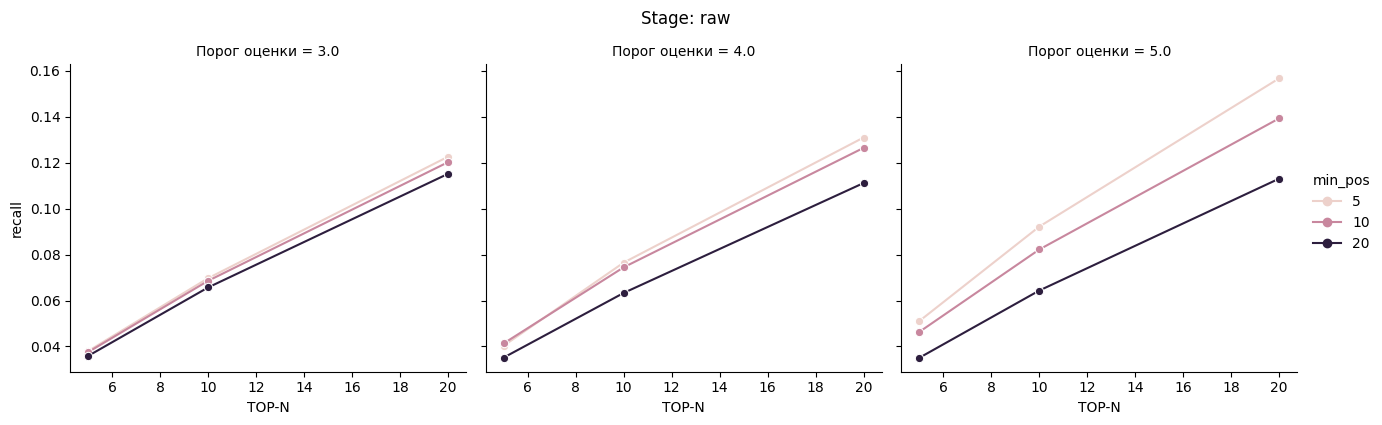

    threshold  min_pos   k      ndcg
30        3.0       20   5  0.120083
31        3.0       20  10  0.121073
2         3.0        5  20  0.132665


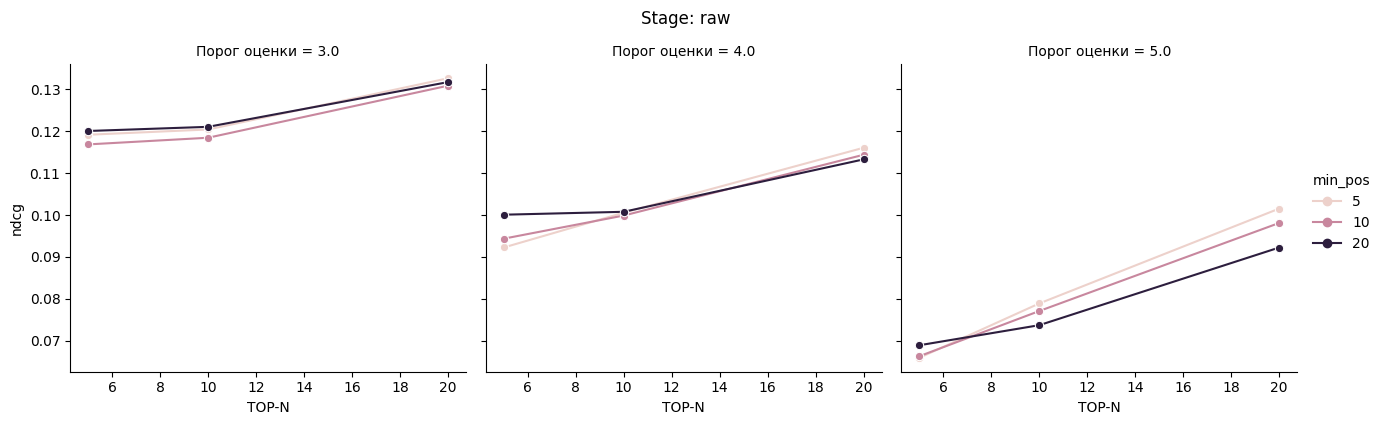

    threshold  min_pos   k   hitrate
30        3.0       20   5  0.404548
31        3.0       20  10  0.589988
32        3.0       20  20  0.769434


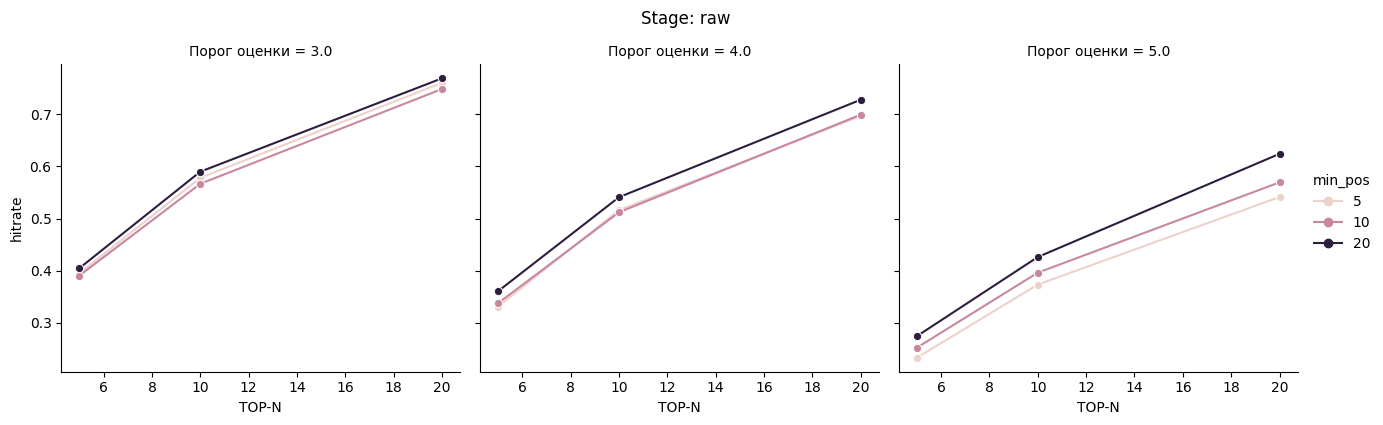

    threshold  min_pos   k    recall
93        5.0        5   5  0.052944
94        5.0        5  10  0.094505
95        5.0        5  20  0.160157


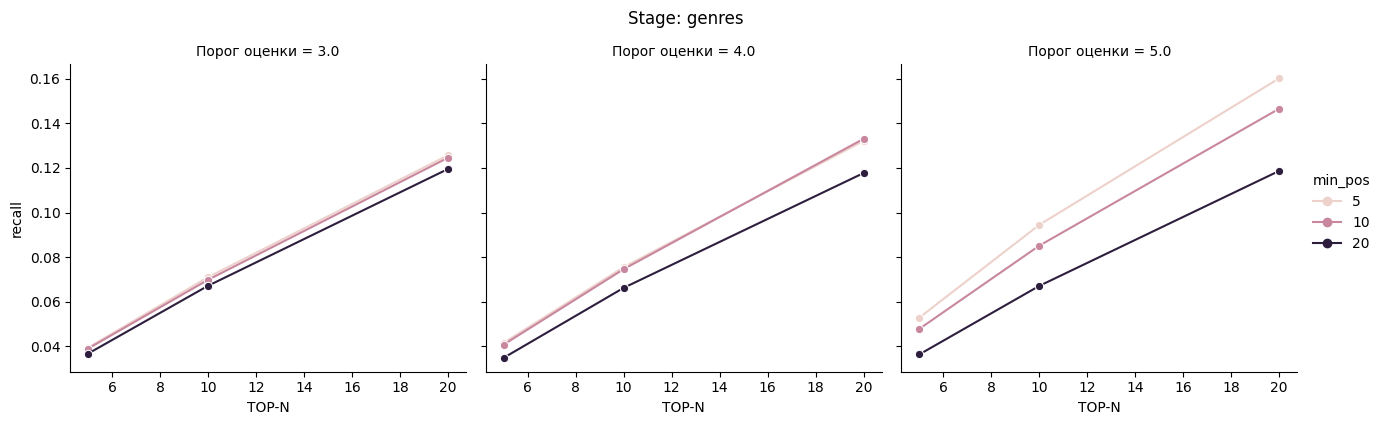

    threshold  min_pos   k      ndcg
33        3.0       20   5  0.126599
34        3.0       20  10  0.125788
5         3.0        5  20  0.136766


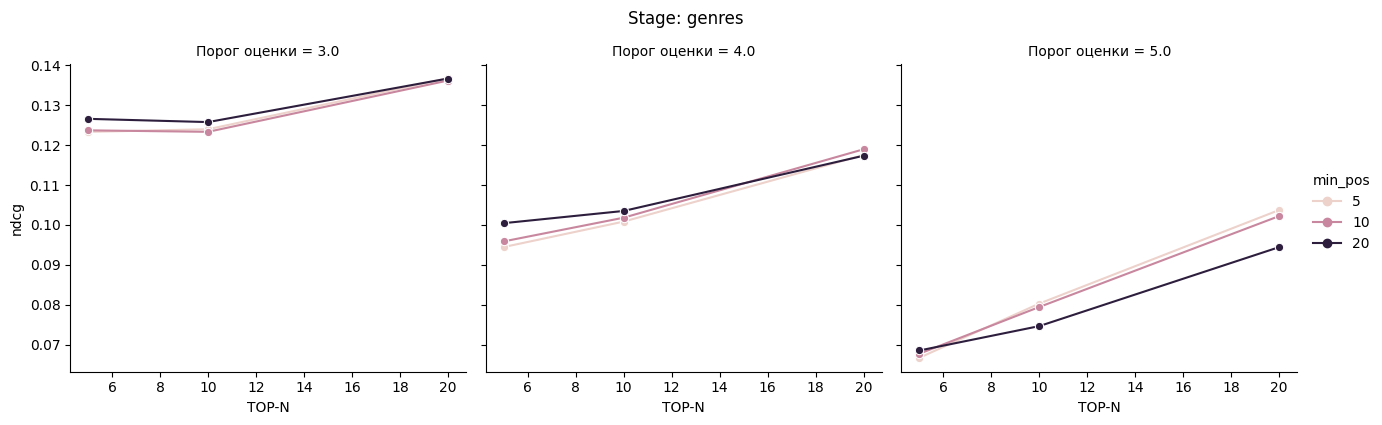

    threshold  min_pos   k   hitrate
33        3.0       20   5  0.404372
34        3.0       20  10  0.578882
35        3.0       20  20  0.748986


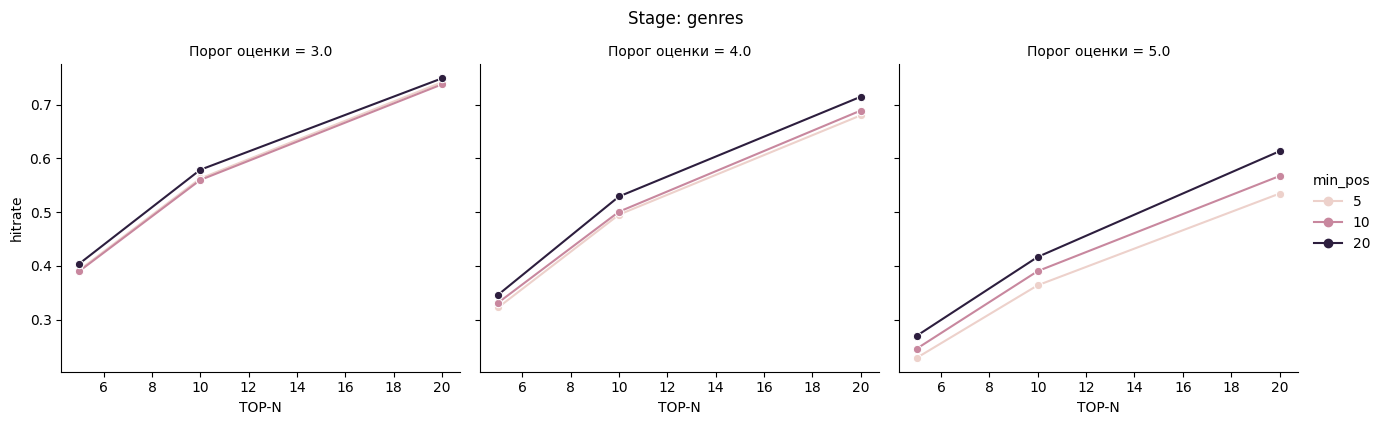

    threshold  min_pos   k    recall
96        5.0        5   5  0.054364
97        5.0        5  10  0.096959
98        5.0        5  20  0.160723


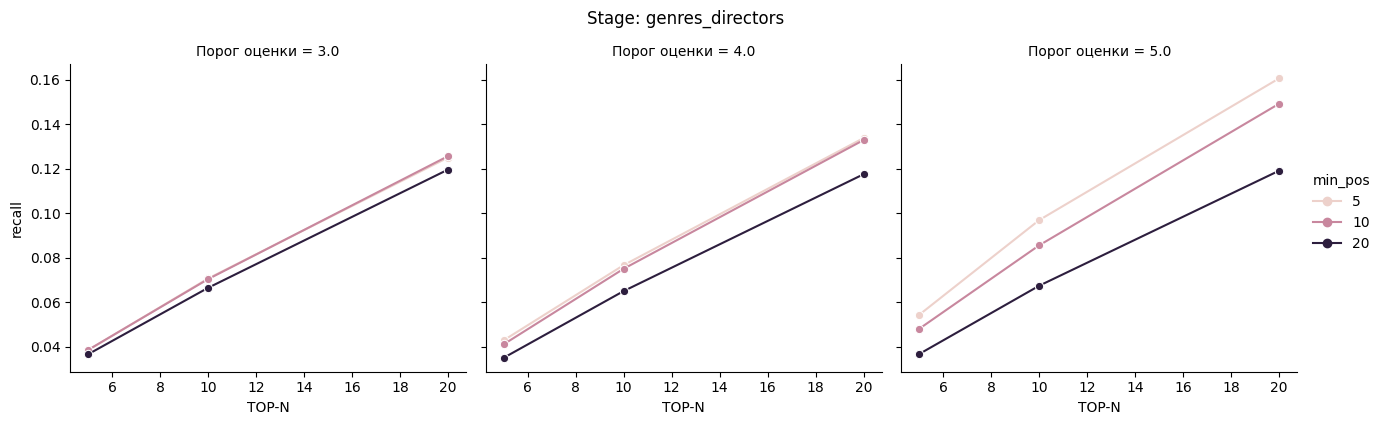

    threshold  min_pos   k      ndcg
36        3.0       20   5  0.126780
37        3.0       20  10  0.125298
38        3.0       20  20  0.137105


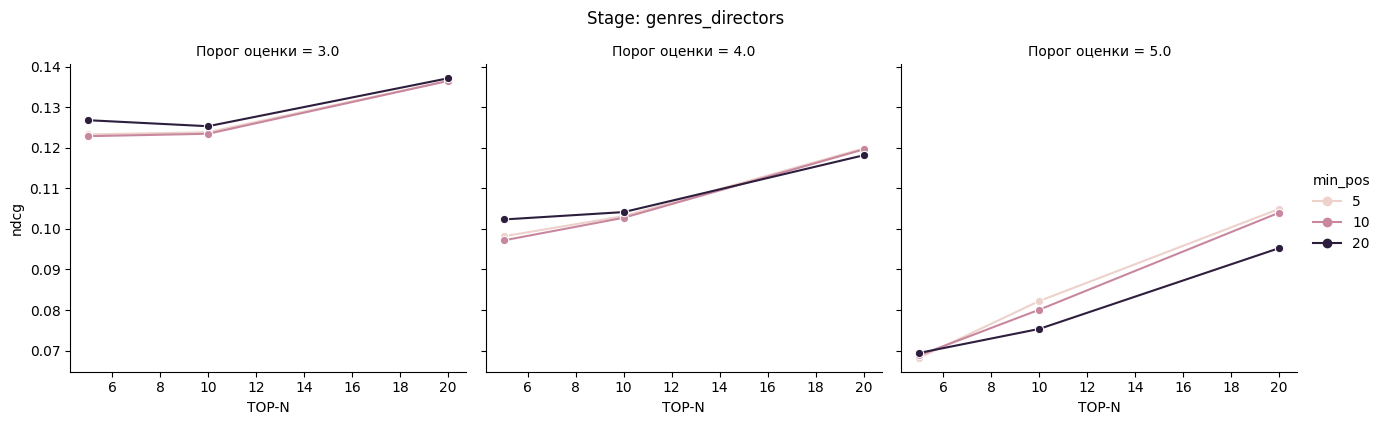

    threshold  min_pos   k   hitrate
36        3.0       20   5  0.409836
37        3.0       20  10  0.580469
38        3.0       20  20  0.759563


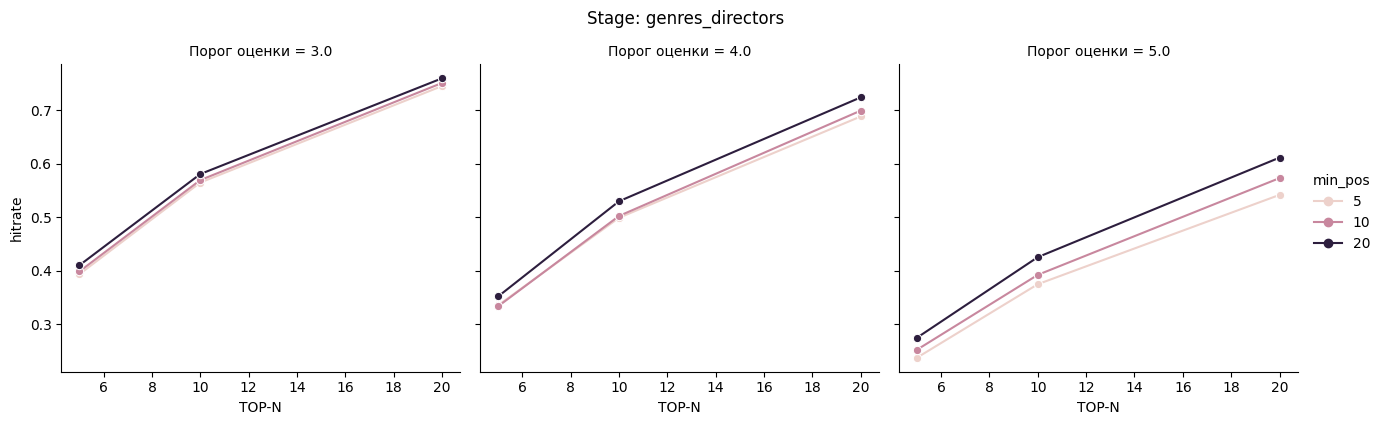

     threshold  min_pos   k    recall
99         5.0        5   5  0.052788
100        5.0        5  10  0.094432
101        5.0        5  20  0.160363


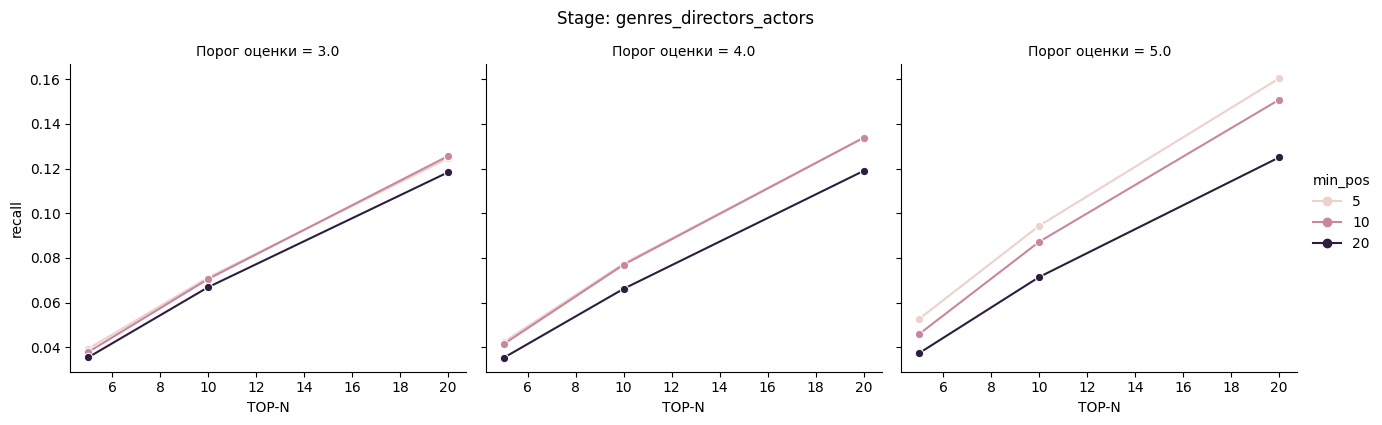

    threshold  min_pos   k      ndcg
39        3.0       20   5  0.127460
40        3.0       20  10  0.127141
26        3.0       10  20  0.137486


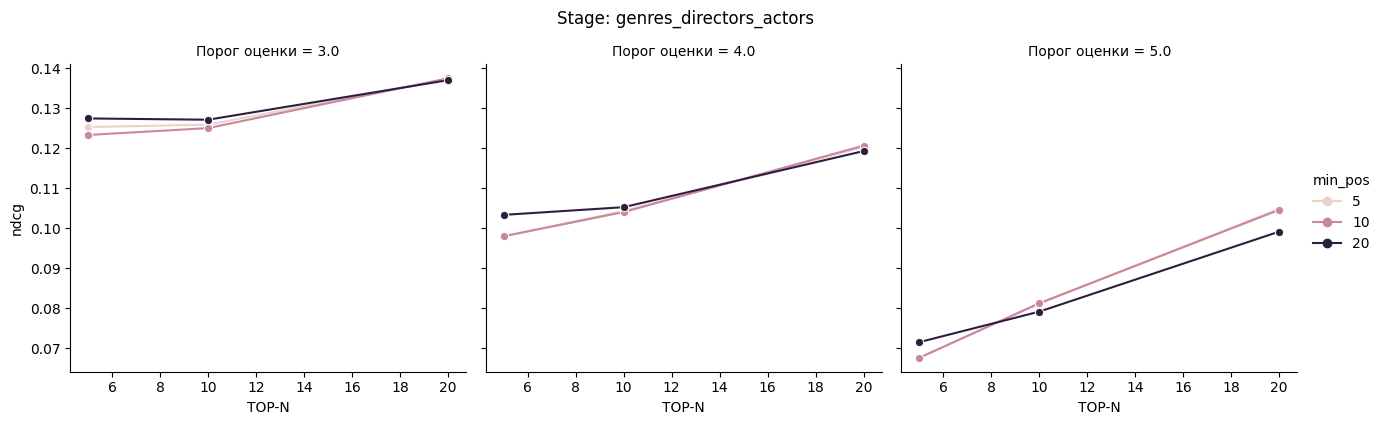

    threshold  min_pos   k   hitrate
39        3.0       20   5  0.405958
40        3.0       20  10  0.587520
41        3.0       20  20  0.753746


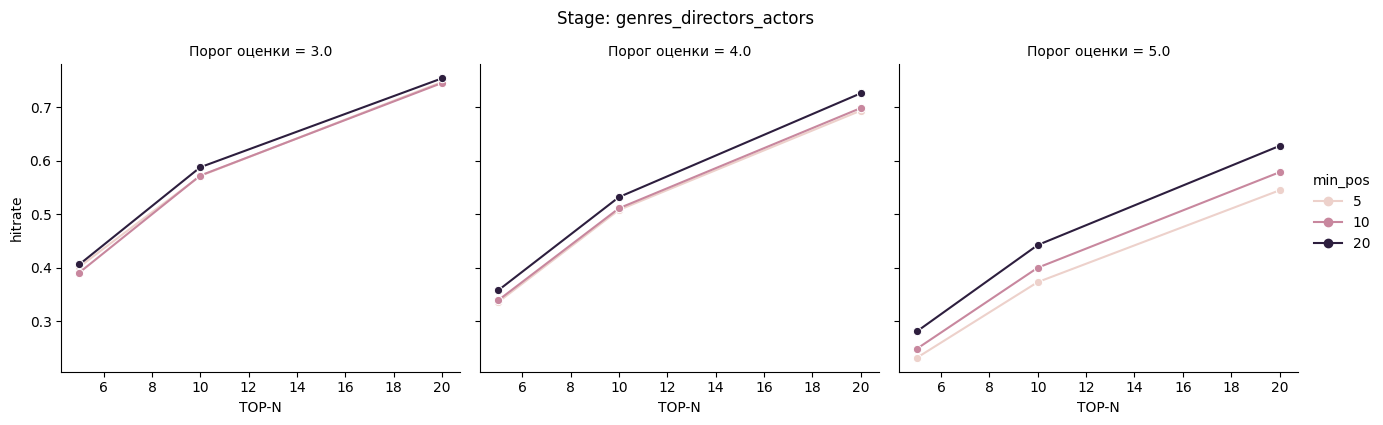

     threshold  min_pos   k    recall
102        5.0        5   5  0.054496
103        5.0        5  10  0.097046
104        5.0        5  20  0.163271


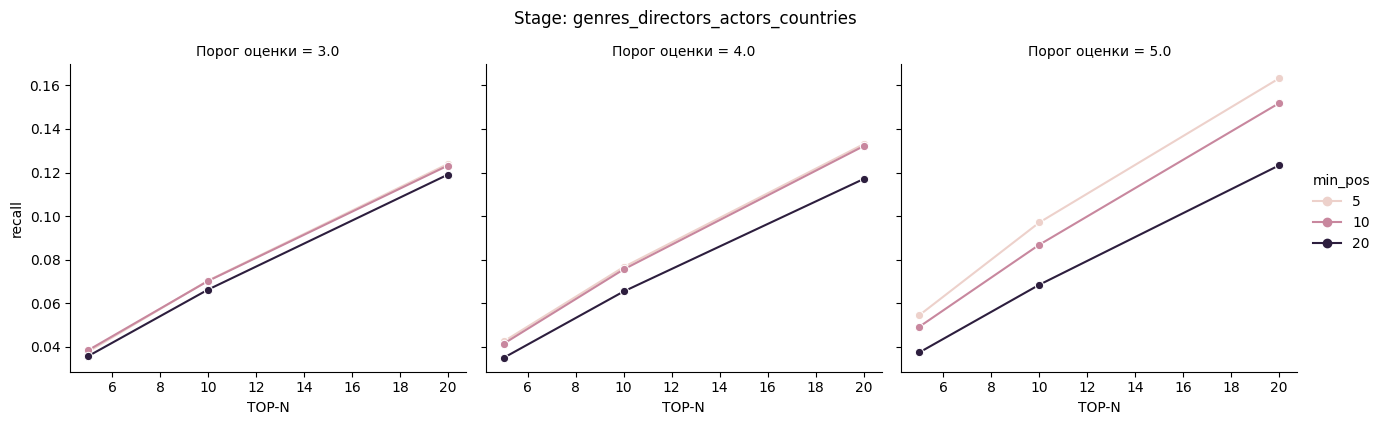

    threshold  min_pos   k      ndcg
42        3.0       20   5  0.126441
43        3.0       20  10  0.126204
44        3.0       20  20  0.137668


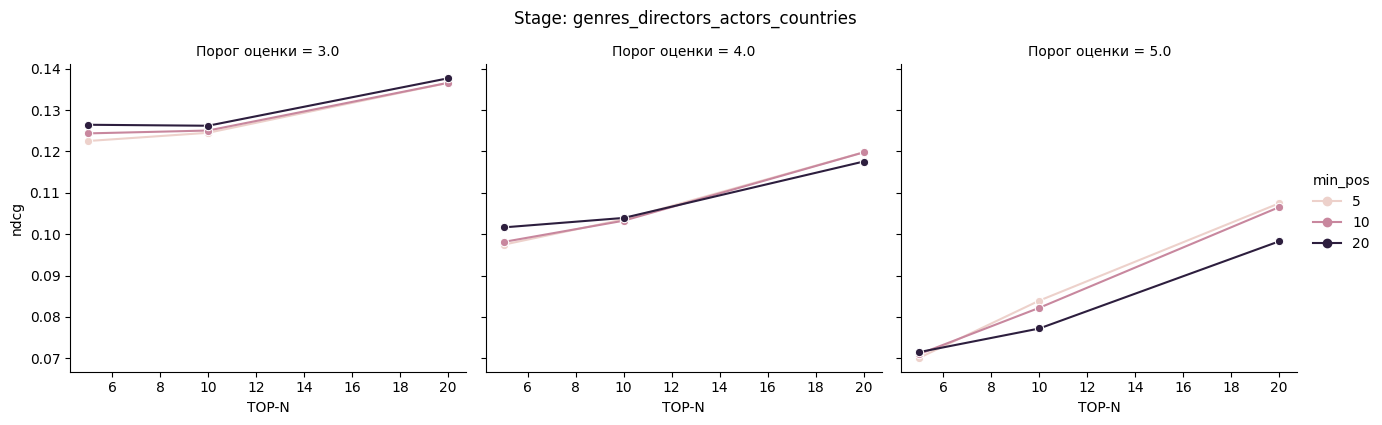

    threshold  min_pos   k   hitrate
42        3.0       20   5  0.400846
43        3.0       20  10  0.582760
44        3.0       20  20  0.756390


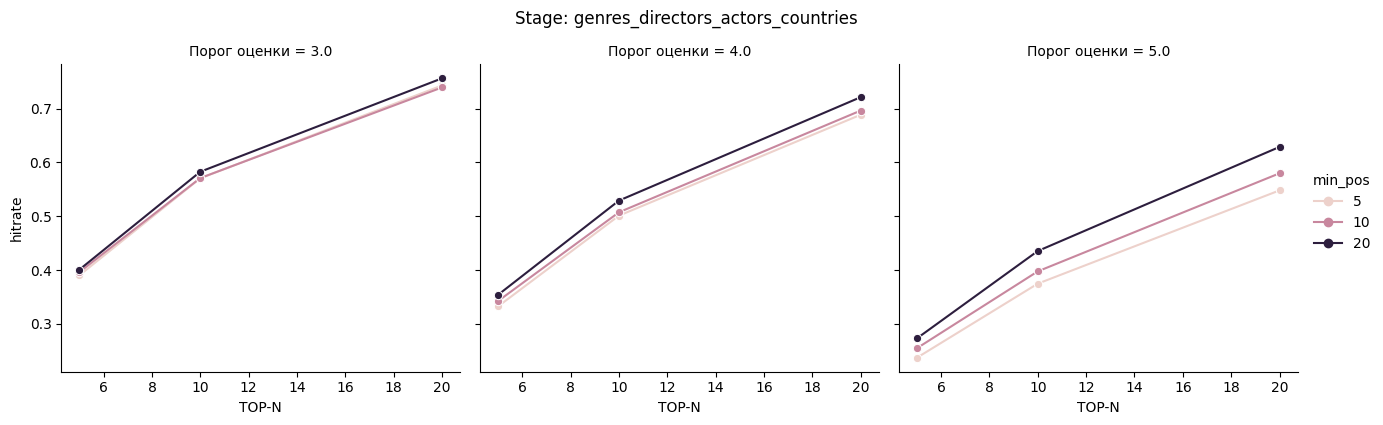

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

for stage in context_order:
    df_stage = lightfm_results_df[lightfm_results_df["context_stage"] == stage]

    for metric in ["recall", "ndcg", "hitrate"]:
        max_per_k = df_stage.loc[df_stage.groupby("k")[metric].idxmax()].sort_values("k")[["threshold", "min_pos", "k", metric]]
        print(max_per_k.head(3))
        g = sns.relplot(
            data=df_stage,
            x="k",
            y=metric,
            hue="min_pos",
            col="threshold",
            kind="line",
            marker="o",
            height=4,
            aspect=1.1
        )

        g.set_axis_labels("TOP-N", metric)
        g.set_titles("Порог оценки = {col_name}")
        g.fig.suptitle(f"Stage: {stage}", y=1.05)

        plt.show()

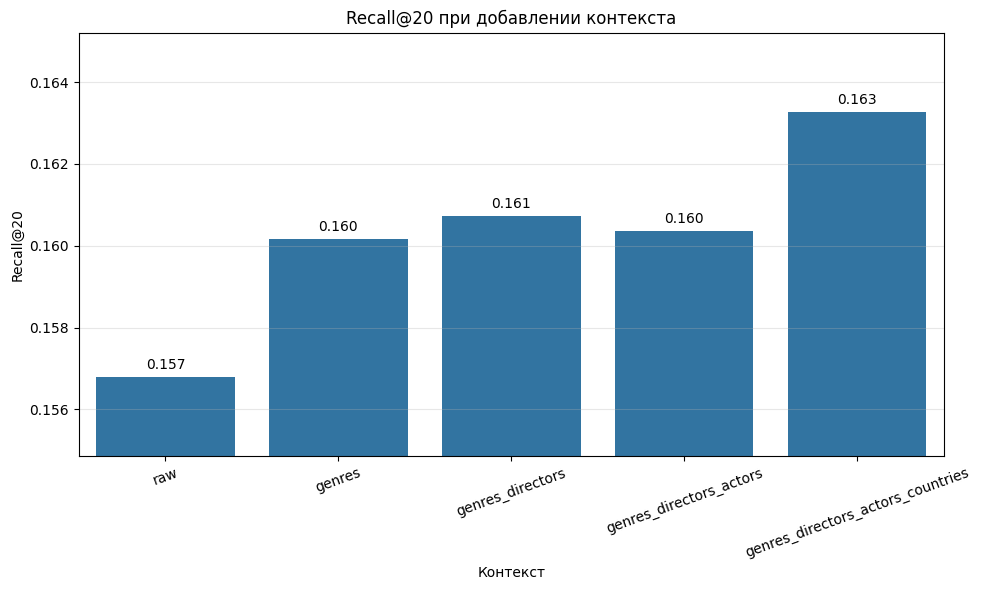

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

recall_bar_df = lightfm_results_df[
    (lightfm_results_df["threshold"] == 5.0) &
    (lightfm_results_df["min_pos"] == 5) &
    (lightfm_results_df["k"] == 20)
].copy()

recall_bar_df["context_stage"] = pd.Categorical(
    recall_bar_df["context_stage"],
    categories=context_order,
    ordered=True
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=recall_bar_df,
    x="context_stage",
    y="recall"
)

# 🔥 ключевая часть — сужаем диапазон
y_min = recall_bar_df["recall"].min()
y_max = recall_bar_df["recall"].max()

margin = (y_max - y_min) * 0.3 if y_max > y_min else 0.005
plt.ylim(y_min - margin, y_max + margin)

plt.title("Recall@20 при добавлении контекста")
plt.xlabel("Контекст")
plt.ylabel("Recall@20")
plt.xticks(rotation=20)

# подписи
for i, row in enumerate(recall_bar_df.sort_values("context_stage")["recall"]):
    ax.text(i, row + margin * 0.1, f"{row:.3f}", ha='center')

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

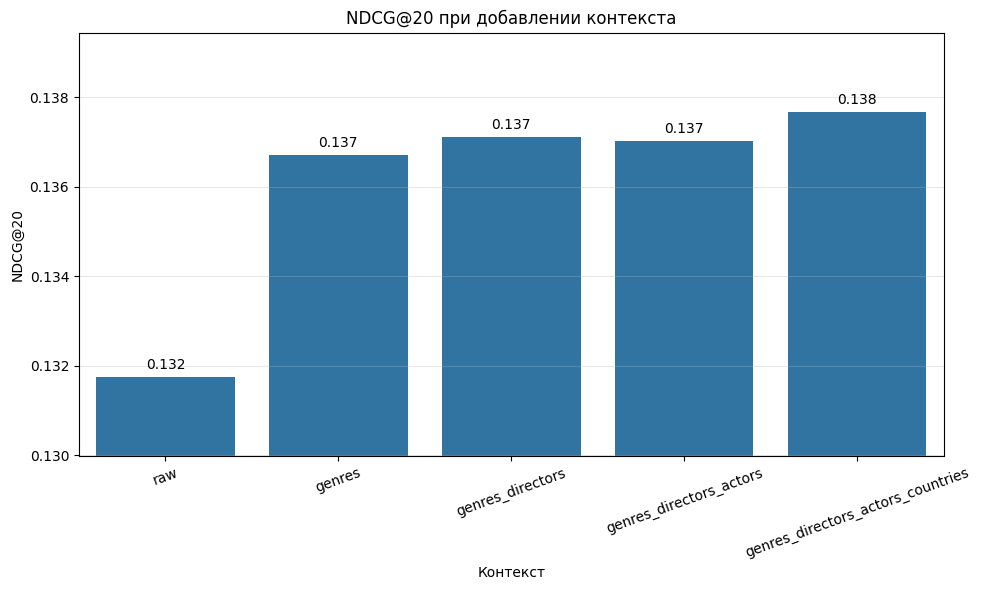

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

recall_bar_df = lightfm_results_df[
    (lightfm_results_df["threshold"] == 3.0) &
    (lightfm_results_df["min_pos"] == 20) &
    (lightfm_results_df["k"] == 20)
].copy()

recall_bar_df["context_stage"] = pd.Categorical(
    recall_bar_df["context_stage"],
    categories=context_order,
    ordered=True
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=recall_bar_df,
    x="context_stage",
    y="ndcg"
)

# 🔥 ключевая часть — сужаем диапазон
y_min = recall_bar_df["ndcg"].min()
y_max = recall_bar_df["ndcg"].max()

margin = (y_max - y_min) * 0.3 if y_max > y_min else 0.005
plt.ylim(y_min - margin, y_max + margin)

plt.title("NDCG@20 при добавлении контекста")
plt.xlabel("Контекст")
plt.ylabel("NDCG@20")
plt.xticks(rotation=20)

# подписи
for i, row in enumerate(recall_bar_df.sort_values("context_stage")["ndcg"]):
    ax.text(i, row + margin * 0.1, f"{row:.3f}", ha='center')

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

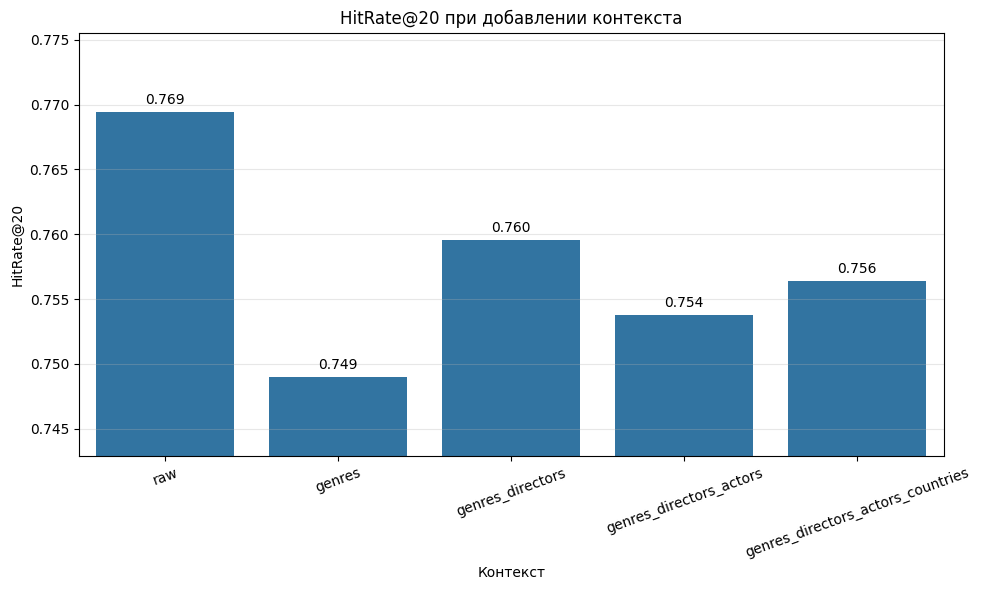

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

recall_bar_df = lightfm_results_df[
    (lightfm_results_df["threshold"] == 3.0) &
    (lightfm_results_df["min_pos"] == 20) &
    (lightfm_results_df["k"] == 20)
].copy()

recall_bar_df["context_stage"] = pd.Categorical(
    recall_bar_df["context_stage"],
    categories=context_order,
    ordered=True
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=recall_bar_df,
    x="context_stage",
    y="hitrate"
)

# 🔥 ключевая часть — сужаем диапазон
y_min = recall_bar_df["hitrate"].min()
y_max = recall_bar_df["hitrate"].max()

margin = (y_max - y_min) * 0.3 if y_max > y_min else 0.005
plt.ylim(y_min - margin, y_max + margin)

plt.title("HitRate@20 при добавлении контекста")
plt.xlabel("Контекст")
plt.ylabel("HitRate@20")
plt.xticks(rotation=20)

# подписи
for i, row in enumerate(recall_bar_df.sort_values("context_stage")["hitrate"]):
    ax.text(i, row + margin * 0.1, f"{row:.3f}", ha='center')

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Cold-start эксперимент для LightFM

В этом блоке LightFM оценивается в тех же условиях synthetic cold-start, что и DeepWalk/HGT.
Сначала выбираются пользователи с достаточной историей взаимодействий, затем доля `cold_user_fraction = 0.2` таких пользователей переводится в cold-start группу. Для них в обучающей выборке остаются только первые `cold_n` взаимодействий, а остальные взаимодействия используются в тестовой выборке.

Для warm-пользователей используется leave-one-out разбиение: последнее взаимодействие переносится в test, вся предыдущая история остается в train. Итоговая оценка считается только по cold-start пользователям.


In [23]:
from common.cold_start import (
    make_synthetic_cold_start_split,
    get_eval_users,
    filter_interactions_by_users,
    build_seen_items_map,
    build_ground_truth_map,
    summarize_split_result,
)

In [24]:
def evaluate_lightfm_ranking_for_users(
    model: LightFM,
    dataset: Dataset,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    eval_users,
    item_features=None,
    user_features=None,
    user_col: str = "user_id",
    item_col: str = "movie_id",
    k_list=(5, 10, 20),
) -> pd.DataFrame:

    seen_items_map = build_seen_items_map(
        train_df=train_df,
        user_col=user_col,
        item_col=item_col,
    )

    ground_truth_map = build_ground_truth_map(
        test_df=test_df,
        user_col=user_col,
        item_col=item_col,
    )

    user_id_map, _, item_id_map, _ = dataset.mapping()
    idx2item = {idx: item_id for item_id, idx in item_id_map.items()}
    all_item_indices = np.arange(len(item_id_map), dtype=np.int32)

    eval_users = set(eval_users)
    rows = []

    for k in k_list:
        recommendations = {}
        ground_truth = {}

        for user_id in eval_users:
            if user_id not in user_id_map:
                continue

            relevant_items = ground_truth_map.get(user_id, set())
            if len(relevant_items) == 0:
                continue

            seen_items = seen_items_map.get(user_id, set())
            user_idx = user_id_map[user_id]

            scores = model.predict(
                user_ids=user_idx,
                item_ids=all_item_indices,
                item_features=item_features,
                user_features=user_features,
            )

            ranked_internal_items = np.argsort(-scores)

            recs = []
            for internal_item_idx in ranked_internal_items:
                item_id = idx2item[int(internal_item_idx)]

                if item_id in seen_items:
                    continue

                recs.append(item_id)

                if len(recs) == k:
                    break

            if len(recs) == 0:
                continue

            recommendations[user_id] = recs
            ground_truth[user_id] = relevant_items

        if len(ground_truth) == 0:
            continue

        metrics = evaluate_ranking(
            recommendations=recommendations,
            ground_truth=ground_truth,
            k=k,
        )

        rows.append({
            "k": k,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "map": metrics["map"],
            "ndcg": metrics["ndcg"],
            "mrr": metrics["mrr"],
            "hitrate": metrics["hitrate"],
            "users_evaluated": len(ground_truth),
        })

    return pd.DataFrame(rows)

In [25]:
def build_lightfm_dataset_for_stage(
    train_df: pd.DataFrame,
    context_stage: str,
    progressive_item_feature_maps: dict,
    user_feature_map: dict,
    user_col: str = "user_id",
    item_col: str = "movie_id",
):

    train_user_ids = sorted(train_df[user_col].unique())
    train_item_ids = sorted(train_df[item_col].unique())
    train_pairs = list(zip(train_df[user_col], train_df[item_col]))

    item_context_stage = (
        "genres_directors_actors_countries"
        if context_stage == "full_context"
        else context_stage
    )

    movie_feature_map_train = {
        movie_id: progressive_item_feature_maps[item_context_stage].get(movie_id, [])
        for movie_id in train_item_ids
    }

    user_feature_map_train = {
        user_id: user_feature_map.get(user_id, [])
        for user_id in train_user_ids
    }

    all_item_features = sorted({
        token
        for tokens in movie_feature_map_train.values()
        for token in tokens
    })

    all_user_features = sorted({
        token
        for tokens in user_feature_map_train.values()
        for token in tokens
    })

    dataset = Dataset()

    if context_stage == "raw":
        dataset.fit(
            users=train_user_ids,
            items=train_item_ids,
        )
    elif context_stage == "full_context":
        dataset.fit(
            users=train_user_ids,
            items=train_item_ids,
            user_features=all_user_features,
            item_features=all_item_features,
        )
    else:
        dataset.fit(
            users=train_user_ids,
            items=train_item_ids,
            item_features=all_item_features,
        )

    interactions, weights = dataset.build_interactions(train_pairs)

    item_feature_tuples = [
        (movie_id, movie_feature_map_train[movie_id])
        for movie_id in train_item_ids
    ]

    item_features = (
        None
        if context_stage == "raw"
        else dataset.build_item_features(item_feature_tuples)
    )

    user_feature_tuples = [
        (user_id, user_feature_map_train[user_id])
        for user_id in train_user_ids
    ]

    user_features = (
        dataset.build_user_features(user_feature_tuples)
        if context_stage == "full_context"
        else None
    )

    return {
        "dataset": dataset,
        "interactions": interactions,
        "weights": weights,
        "item_features": item_features,
        "user_features": user_features,
        "train_user_ids": train_user_ids,
        "train_item_ids": train_item_ids,
        "item_feature_dim": 0 if item_features is None else item_features.shape[1],
        "user_feature_dim": 0 if user_features is None else user_features.shape[1],
    }

In [26]:
def run_lightfm_cold_start_experiments(
    base_df: pd.DataFrame,
    threshold: float,
    min_pos: int,
    context_stages=None,
    cold_n_values=(1, 3, 5),
    cold_user_fraction: float = 0.2,
    min_interactions_for_cold: int = 20,
    warm_last_n: int = 1,
    no_components: int = 64,
    loss: str = "warp",
    learning_rate: float = 0.05,
    epochs: int = 80,
    num_threads: int = 8,
    k_list=(5, 10, 20),
    seed: int = 42,
):

    if context_stages is None:
        context_stages = context_order

    cold_rows = []
    split_summaries = []

    for cold_n in cold_n_values:
        split_result = make_synthetic_cold_start_split(
            interactions=base_df,
            user_col="user_id",
            item_col="movie_id",
            time_col="datetime",
            cold_user_fraction=cold_user_fraction,
            cold_n=cold_n,
            min_interactions_for_cold=min_interactions_for_cold,
            warm_last_n=warm_last_n,
            random_state=seed,
        )

        train_df = split_result.train_df
        test_df = split_result.test_df

        eval_users = get_eval_users(
            split_result=split_result,
            mode="cold_only",
            user_col="user_id",
        )

        if len(train_df) == 0 or len(test_df) == 0 or len(eval_users) == 0:
            print(f"Skip cold_n={cold_n}: empty train/test or no cold users")
            continue

        split_summary = summarize_split_result(split_result)
        split_summary.insert(0, "cold_n", cold_n)
        split_summary.insert(0, "warm_last_n", warm_last_n)
        split_summary.insert(0, "min_pos", min_pos)
        split_summary.insert(0, "threshold", threshold)
        split_summaries.append(split_summary)

        cold_test_df = filter_interactions_by_users(
            df=test_df,
            users=eval_users,
            user_col="user_id",
        )

        for context_stage in context_stages:
            print(
                f"START LightFM cold-start | stage={context_stage} | "
                f"threshold={threshold} | min_pos={min_pos} | cold_n={cold_n}"
            )

            stage_data = build_lightfm_dataset_for_stage(
                train_df=train_df,
                context_stage=context_stage,
                progressive_item_feature_maps=progressive_item_feature_maps,
                user_feature_map=user_feature_map,
                user_col="user_id",
                item_col="movie_id",
            )

            dataset = stage_data["dataset"]
            interactions = stage_data["interactions"]
            item_features = stage_data["item_features"]
            user_features = stage_data["user_features"]

            user_id_map, _, item_id_map, _ = dataset.mapping()

            test_df_eval = cold_test_df[
                cold_test_df["user_id"].isin(user_id_map.keys()) &
                cold_test_df["movie_id"].isin(item_id_map.keys())
            ].copy()

            if len(test_df_eval) == 0:
                print(
                    f"Skip stage={context_stage}, cold_n={cold_n}: "
                    "empty filtered cold test"
                )
                continue

            model = LightFM(
                no_components=no_components,
                loss=loss,
                learning_rate=learning_rate,
                random_state=seed,
            )

            model.fit(
                interactions=interactions,
                item_features=item_features,
                user_features=user_features,
                epochs=epochs,
                num_threads=num_threads,
                verbose=False,
            )

            summary = evaluate_lightfm_ranking_for_users(
                model=model,
                dataset=dataset,
                train_df=train_df,
                test_df=test_df_eval,
                eval_users=eval_users,
                item_features=item_features,
                user_features=user_features,
                user_col="user_id",
                item_col="movie_id",
                k_list=k_list,
            )

            if len(summary) == 0:
                print(
                    f"Skip stage={context_stage}, cold_n={cold_n}: "
                    "no evaluable users"
                )
                continue

            summary.insert(0, "loss", loss)
            summary.insert(0, "learning_rate", learning_rate)
            summary.insert(0, "epochs", epochs)
            summary.insert(0, "no_components", no_components)
            summary.insert(0, "context_label", context_labels.get(context_stage, context_stage))
            summary.insert(0, "context_stage", context_stage)
            summary.insert(0, "cold_n", cold_n)
            summary.insert(0, "cold_user_fraction", cold_user_fraction)
            summary.insert(0, "min_interactions_for_cold", min_interactions_for_cold)
            summary.insert(0, "warm_last_n", warm_last_n)
            summary.insert(0, "min_pos", min_pos)
            summary.insert(0, "threshold", threshold)

            summary["train_edges"] = len(train_df)
            summary["test_edges"] = len(test_df)
            summary["test_edges_eval"] = len(test_df_eval)
            summary["n_users_train"] = train_df["user_id"].nunique()
            summary["n_items_train"] = train_df["movie_id"].nunique()
            summary["item_feature_dim"] = stage_data["item_feature_dim"]
            summary["user_feature_dim"] = stage_data["user_feature_dim"]
            summary["nnz"] = interactions.nnz
            summary["cold_users"] = len(split_result.cold_users)
            summary["eligible_cold_users"] = len(split_result.eligible_cold_users)

            cold_rows.append(summary)

            print(
                f"Done stage={context_stage} | cold_n={cold_n} | "
                f"users_eval={int(summary['users_evaluated'].iloc[0])} | "
                f"train={len(train_df)} | test_eval={len(test_df_eval)}"
            )

    cold_results_df = (
        pd.concat(cold_rows, ignore_index=True)
        if cold_rows
        else pd.DataFrame()
    )

    split_summary_df = (
        pd.concat(split_summaries, ignore_index=True)
        if split_summaries
        else pd.DataFrame()
    )

    return cold_results_df, split_summary_df

In [27]:
LIGHTFM_COLD_THRESHOLD = 4.0
LIGHTFM_COLD_MIN_POS = 5

lightfm_cold_base_df = build_edges(
    data=rates,
    threshold=LIGHTFM_COLD_THRESHOLD,
    user_col="user_id",
    item_col="movie_id",
    rating_col="rating",
    time_col="datetime",
)

lightfm_cold_base_df = filter_users_min_pos(
    data=lightfm_cold_base_df,
    min_pos=LIGHTFM_COLD_MIN_POS,
    user_col="user_id",
)

print(
    "base_df:",
    lightfm_cold_base_df.shape,
    "| users:", lightfm_cold_base_df["user_id"].nunique(),
    "| items:", lightfm_cold_base_df["movie_id"].nunique(),
)

lightfm_cold_df, lightfm_cold_split_df = run_lightfm_cold_start_experiments(
    base_df=lightfm_cold_base_df,
    threshold=LIGHTFM_COLD_THRESHOLD,
    min_pos=LIGHTFM_COLD_MIN_POS,

    context_stages=context_order,
    cold_n_values=(1, 3, 5),
    cold_user_fraction=0.2,
    min_interactions_for_cold=20,
    warm_last_n=1,

    no_components=64,
    loss="warp",
    learning_rate=0.05,
    epochs=80,
    num_threads=8,

    k_list=(5, 10, 20),
    seed=42,
)

lightfm_cold_df

base_df: (545628, 3) | users: 6033 | items: 3197
START LightFM cold-start | stage=raw | threshold=4.0 | min_pos=5 | cold_n=1
Done stage=raw | cold_n=1 | users_eval=1017 | train=433839 | test_eval=106742
START LightFM cold-start | stage=genres | threshold=4.0 | min_pos=5 | cold_n=1
Done stage=genres | cold_n=1 | users_eval=1017 | train=433839 | test_eval=106742
START LightFM cold-start | stage=genres_directors | threshold=4.0 | min_pos=5 | cold_n=1
Done stage=genres_directors | cold_n=1 | users_eval=1017 | train=433839 | test_eval=106742
START LightFM cold-start | stage=genres_directors_actors | threshold=4.0 | min_pos=5 | cold_n=1
Done stage=genres_directors_actors | cold_n=1 | users_eval=1017 | train=433839 | test_eval=106742
START LightFM cold-start | stage=genres_directors_actors_countries | threshold=4.0 | min_pos=5 | cold_n=1
Done stage=genres_directors_actors_countries | cold_n=1 | users_eval=1017 | train=433839 | test_eval=106742
START LightFM cold-start | stage=raw | threshold=

,threshold,min_pos,warm_last_n,min_interactions_for_cold,cold_user_fraction,cold_n,context_stage,context_label,no_components,epochs,...,train_edges,test_edges,test_edges_eval,n_users_train,n_items_train,item_feature_dim,user_feature_dim,nnz,cold_users,eligible_cold_users
0,4.0,5,1,20,0.2,1,raw,Raw LightFM,64,80,...,433839,111789,106742,6033,3167,0,0,433839,1017,5083
1,4.0,5,1,20,0.2,1,raw,Raw LightFM,64,80,...,433839,111789,106742,6033,3167,0,0,433839,1017,5083
2,4.0,5,1,20,0.2,1,raw,Raw LightFM,64,80,...,433839,111789,106742,6033,3167,0,0,433839,1017,5083
3,4.0,5,1,20,0.2,1,genres,Genres,64,80,...,433839,111789,106742,6033,3167,3185,0,433839,1017,5083
4,4.0,5,1,20,0.2,1,genres,Genres,64,80,...,433839,111789,106742,6033,3167,3185,0,433839,1017,5083
5,4.0,5,1,20,0.2,1,genres,Genres,64,80,...,433839,111789,106742,6033,3167,3185,0,433839,1017,5083
6,4.0,5,1,20,0.2,1,genres_directors,Genres + Directors,64,80,...,433839,111789,106742,6033,3167,3385,0,433839,1017,5083
7,4.0,5,1,20,0.2,1,genres_directors,Genres + Directors,64,80,...,433839,111789,106742,6033,3167,3385,0,433839,1017,5083
8,4.0,5,1,20,0.2,1,genres_directors,Genres + Directors,64,80,...,433839,111789,106742,6033,3167,3385,0,433839,1017,5083
9,4.0,5,1,20,0.2,1,genres_directors_actors,Genres + Directors + Actors,64,80,...,433839,111789,106742,6033,3167,3585,0,433839,1017,5083


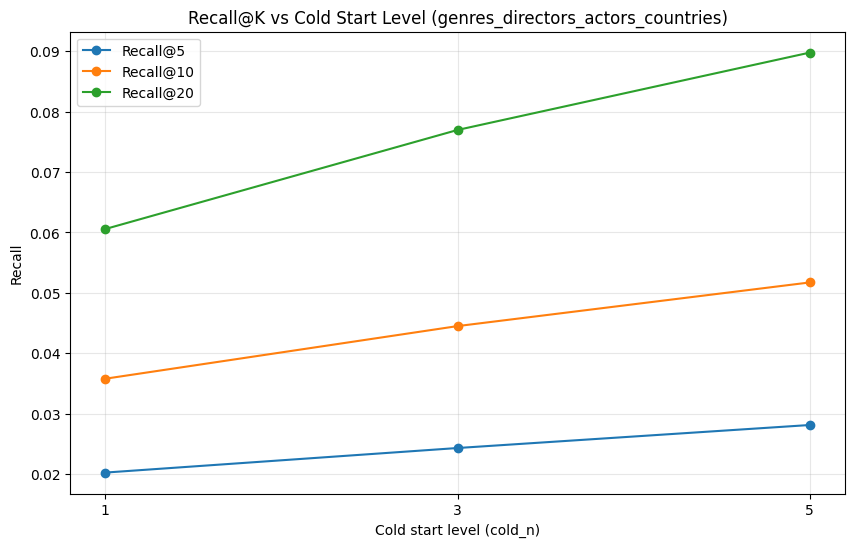

In [30]:
import matplotlib.pyplot as plt

selected_context_stage = "genres_directors_actors_countries"

plot_df = lightfm_cold_df[
    lightfm_cold_df["context_stage"] == selected_context_stage
].copy()

plt.figure(figsize=(10, 6))

for k in sorted(plot_df["k"].unique()):
    subset = plot_df[plot_df["k"] == k].sort_values("cold_n")

    plt.plot(
        subset["cold_n"],
        subset["recall"],
        marker="o",
        label=f"Recall@{k}"
    )

plt.title(f"Recall@K vs Cold Start Level ({selected_context_stage})")
plt.xlabel("Cold start level (cold_n)")
plt.ylabel("Recall")
plt.xticks(sorted(plot_df["cold_n"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

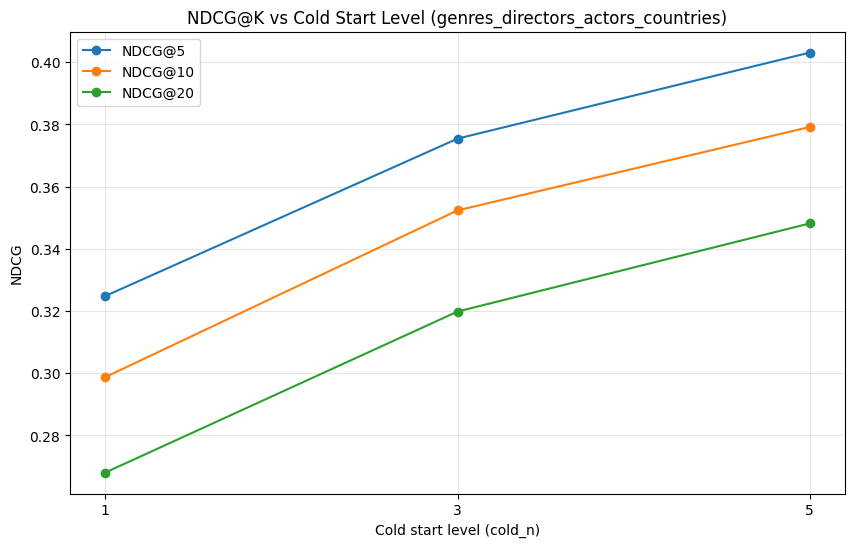

In [32]:
plt.figure(figsize=(10, 6))

for k in sorted(plot_df["k"].unique()):
    subset = plot_df[plot_df["k"] == k].sort_values("cold_n")

    plt.plot(
        subset["cold_n"],
        subset["ndcg"],
        marker="o",
        label=f"NDCG@{k}"
    )

plt.title(f"NDCG@K vs Cold Start Level ({selected_context_stage})")
plt.xlabel("Cold start level (cold_n)")
plt.ylabel("NDCG")
plt.xticks(sorted(plot_df["cold_n"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

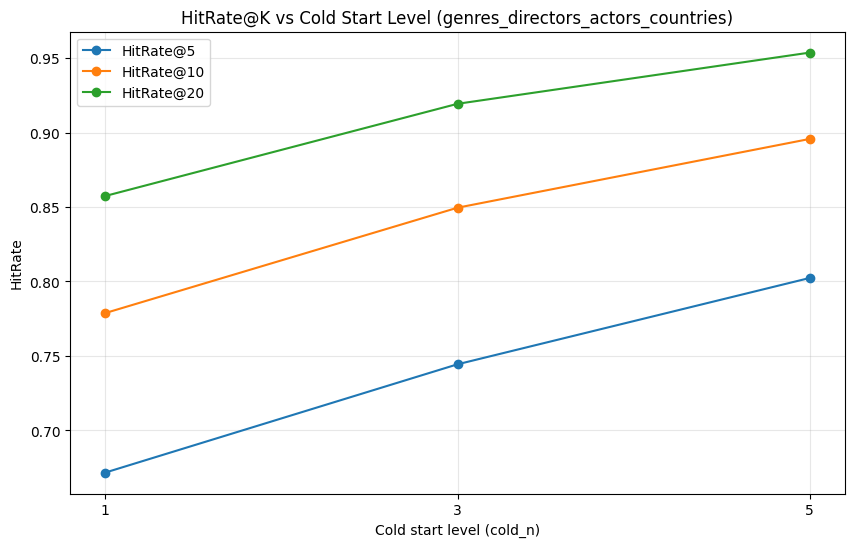

In [33]:
plt.figure(figsize=(10, 6))

for k in sorted(plot_df["k"].unique()):
    subset = plot_df[plot_df["k"] == k].sort_values("cold_n")

    plt.plot(
        subset["cold_n"],
        subset["hitrate"],
        marker="o",
        label=f"HitRate@{k}"
    )

plt.title(f"HitRate@K vs Cold Start Level ({selected_context_stage})")
plt.xlabel("Cold start level (cold_n)")
plt.ylabel("HitRate")
plt.xticks(sorted(plot_df["cold_n"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()